In [9]:
import numpy as np
import matplotlib as mpl
import matplotlib.pyplot as plt
import sys
import os
sys.path.insert(0, os.path.abspath('../../../'))
# Utility to make plots look nice
from kea.utils.plotting import modify_latex_rc, make_ax_step, pretty_axes
# modify_latex_rc()
# modify_latex_rc()

In [10]:
from kea.simulator import make_solenoidal_field
from kea.utils import geometry

In [11]:
N = 256
D = 2
grid_dims = (N,)*D
L = geometry.DEFAULT_PHYS_SCALE

dx, dk = geometry.get_dxdk(grid_dims)
dk = dk[0]

alpha = 8./3.
ki, kd = (2.*dk, 50.*dk)
vx, vy = make_solenoidal_field(grid_dims,
                gauss_spectrum_kwargs={'powerlaw': -alpha, 'break_1': ki, 'break_2': kd},
                gauss_spectrum_function='powerlaw_with_exponentials',
                multifractal_scaling=0.25,
                spectrum_function='powerlaw_with_exponentials',
                spectrum_kwargs={'powerlaw': -alpha, 'break_1': ki, 'break_2': kd})

/home/mark/Documents/Kea/src/kea/utils/functions.py:126: RuntimeWarning: divide by zero encountered in power
  result = grid**(powerlaw) * np.exp(-(break_1/grid)**exp_factor_1) * np.exp(-(grid/break_2)**exp_factor_2)
/home/mark/Documents/Kea/src/kea/utils/functions.py:126: RuntimeWarning: divide by zero encountered in divide
  result = grid**(powerlaw) * np.exp(-(break_1/grid)**exp_factor_1) * np.exp(-(grid/break_2)**exp_factor_2)
/home/mark/Documents/Kea/src/kea/utils/functions.py:126: RuntimeWarning: invalid value encountered in multiply
  result = grid**(powerlaw) * np.exp(-(break_1/grid)**exp_factor_1) * np.exp(-(grid/break_2)**exp_factor_2)


In [12]:
print(np.nanmin(vx), np.nanmax(vx))

-21.489751425556435 15.0708327557859


<>:13: SyntaxWarning: invalid escape sequence '\m'
<>:13: SyntaxWarning: invalid escape sequence '\m'
/tmp/ipykernel_18019/2557563128.py:13: SyntaxWarning: invalid escape sequence '\m'
  ax[2].set_title('$u = |\mathbf{u}|$', fontsize=8.)


Text(0.5, 1.0, '$u = |\\mathbf{u}|$')

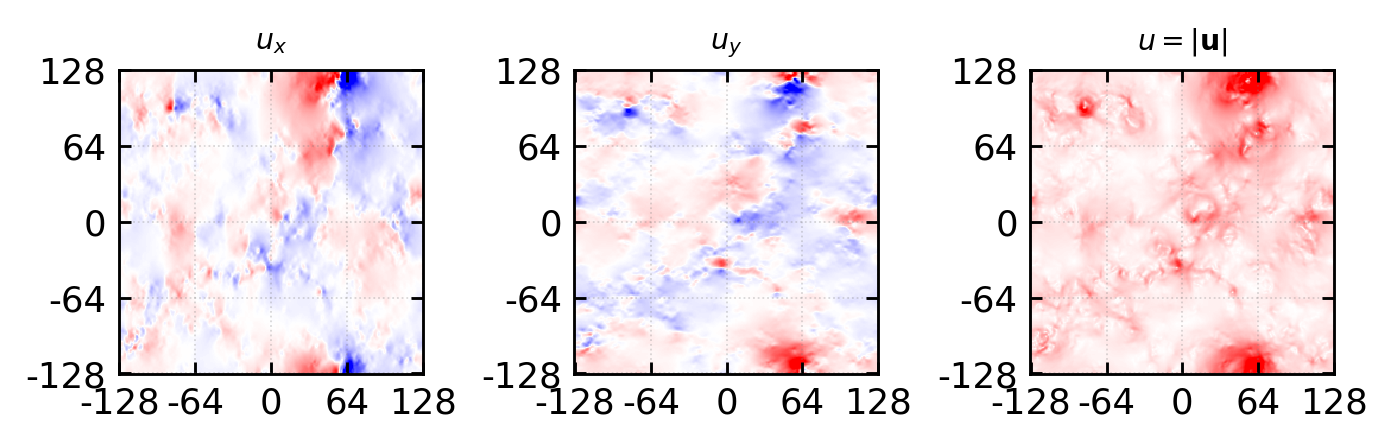

In [13]:
fig, ax = plt.subplots(1, 3, figsize=(1.75*3.5, 2.), dpi=256)
ax[0].imshow(vx, cmap='bwr', interpolation='none', origin='lower', vmin=-10, vmax=10.)
ax[1].imshow(vy, cmap='bwr', interpolation='none', origin='lower', vmin=-10, vmax=10.)
ax[2].imshow(np.sqrt(vx**2 + vy**2), cmap='bwr', interpolation='none', origin='lower', vmin=-10, vmax=10.)
t, l = make_ax_step(N)
for axx in ax:
    pretty_axes(axx)
    axx.set_xticks(t, l)
    axx.set_yticks(t, l)
fig.subplots_adjust(wspace=0.5)
ax[0].set_title('$u_x$', fontsize=8.)
ax[1].set_title('$u_y$', fontsize=8.)
ax[2].set_title('$u = |\mathbf{u}|$', fontsize=8.)

In [14]:
from kea.statistics.spectra import fourier_modal_spectrum, bin_spectrum

In [15]:
from kea.utils import functions
kvec = geometry.get_kvec(grid_dims)
k_mesh = geometry.get_mesh(kvec)
fek_a = functions.powerlaw_with_exponentials(k_mesh, **{'powerlaw': -alpha, 'break_1': ki, 'break_2': kd})
k, fek_a, _ = bin_spectrum(kvec, fek_a, spec_type='integrated')

/home/mark/Documents/Kea/src/kea/utils/functions.py:126: RuntimeWarning: divide by zero encountered in power
  result = grid**(powerlaw) * np.exp(-(break_1/grid)**exp_factor_1) * np.exp(-(grid/break_2)**exp_factor_2)
/home/mark/Documents/Kea/src/kea/utils/functions.py:126: RuntimeWarning: divide by zero encountered in divide
  result = grid**(powerlaw) * np.exp(-(break_1/grid)**exp_factor_1) * np.exp(-(grid/break_2)**exp_factor_2)
/home/mark/Documents/Kea/src/kea/utils/functions.py:126: RuntimeWarning: invalid value encountered in multiply
  result = grid**(powerlaw) * np.exp(-(break_1/grid)**exp_factor_1) * np.exp(-(grid/break_2)**exp_factor_2)


<>:9: SyntaxWarning: invalid escape sequence '\m'
<>:9: SyntaxWarning: invalid escape sequence '\m'
/tmp/ipykernel_18019/344389534.py:9: SyntaxWarning: invalid escape sequence '\m'
  ax.set_ylabel('PSD, $\mathcal{E}(k)$')


Text(0.5, 0, 'Wavenumber, $k$')

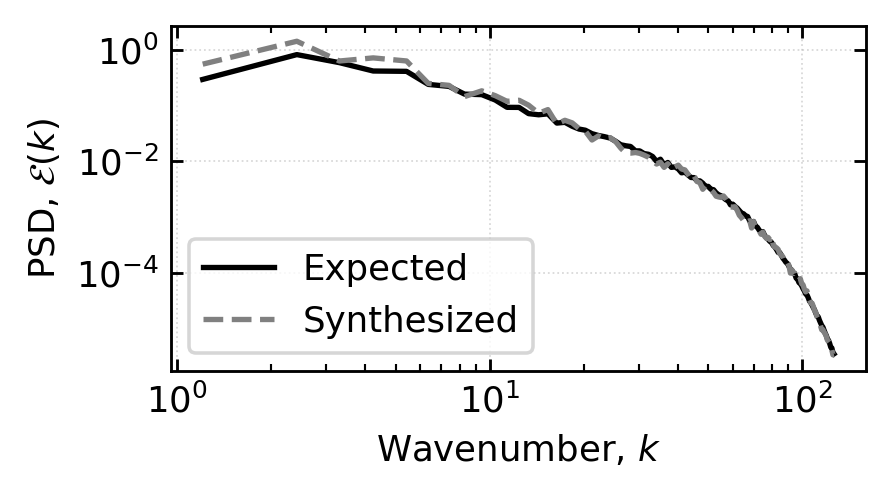

In [16]:
kvec, fekx = fourier_modal_spectrum(vx)
kvec, feky = fourier_modal_spectrum(vy)
k, fek, _ = bin_spectrum(kvec, fekx + feky, spec_type='integrated')
fig, ax = plt.subplots(1, 1, figsize=(3.5, 1.75), dpi=256)
ax.loglog(k, fek_a, linestyle='-', color='black', label='Expected')
ax.loglog(k, fek, linestyle='--', color='gray', label='Synthesized')
ax.legend()
pretty_axes(ax)
ax.set_ylabel('PSD, $\mathcal{E}(k)$')
ax.set_xlabel('Wavenumber, $k$')